# Capítol III — Predicció de churn

**TFG — Grau d'Estadística UB-UPC**  
Segmentació de clients i predicció de churn en el sector retail: una aplicació al dataset d'H&M Group

Aquest notebook desenvolupa un model predictiu del churn dels clients d'H&M definit com Recency > 180 dies. S'avaluen dos models de complexitat creixent: Regressió Logística (baseline) i Random Forest (model final). Genera la Figura 3.1 i les taules 3.1-3.2 del Capítol III.

**Inputs**: `outputs/rfm_segments.parquet`  
**Outputs**: models entrenats (`.joblib`), figures PNG

In [1]:
# ============================================================
# CAPÍTOL III — PREDICCIÓ DE CHURN
# ============================================================
# Aquest notebook utilitza les variables RFM i els segments
# identificats al Capítol II per construir un model predictiu
# de churn (abandonament del client).

# Llibreries bàsiques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Llibreries de modelatge
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

# Configuració estètica (mateixa que abans)
plt.rcdefaults()
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Llibreries i estil carregats")

✓ Llibreries i estil carregats


In [2]:
# Carreguem el dataset final del Capítol II
# (Conté RFM original, transformat, estandarditzat, i el segment assignat)
rfm = pd.read_parquet("../outputs/rfm_segments.parquet")

print(f"Forma del DataFrame: {rfm.shape}")
print(f"\nColumnes disponibles:")
print(rfm.columns.tolist())

print(f"\nPrimeres 3 files (només columnes rellevants):")
rfm[["customer_id", "Recency", "Frequency", "Monetary", "segment_nom"]].head(3)

Forma del DataFrame: (994320, 13)

Columnes disponibles:
['customer_id', 'Recency', 'Frequency', 'Monetary', 'Recency_log', 'Frequency_log', 'Monetary_log', 'Recency_z', 'Frequency_z', 'Monetary_z', 'cluster_K4', 'segment', 'segment_nom']

Primeres 3 files (només columnes rellevants):


,customer_id,Recency,Frequency,Monetary,segment_nom
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,18,12,0.349136,Compradors Recents
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,77,35,0.887542,En Risc
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,8,14,0.559085,Compradors Recents


In [3]:
# ============================================================
# DEFINICIÓ DE CHURN
# ============================================================
# Regla: un client està en churn si la seva Recency > 180 dies
# Justificació: 180 dies = 6 mesos = mig cicle anual; àmpliament
# utilitzat al retail per definir l'abandonament del client.

LLINDAR_CHURN = 180

# Variable target: 1 = churn, 0 = no churn
rfm["churn"] = (rfm["Recency"] > LLINDAR_CHURN).astype(int)

# Verifiquem la distribució de la variable target
print(f"Definició: churn = (Recency > {LLINDAR_CHURN} dies)")
print(f"\nDistribució de la variable target:")
print(rfm["churn"].value_counts())

print(f"\nPercentatge:")
print((rfm["churn"].value_counts(normalize=True) * 100).round(2))

Definició: churn = (Recency > 180 dies)

Distribució de la variable target:
churn
0    740816
1    253504
Name: count, dtype: int64

Percentatge:
churn
0    74.5
1    25.5
Name: proportion, dtype: float64


In [4]:
# Encreuament: churn vs segment
print("Taula d'encreuament: churn × segment")
print("=" * 60)
print(pd.crosstab(rfm["segment_nom"], rfm["churn"],
                  margins=True, margins_name="Total"))

# Mateixa taula però en percentatges per segment
print("\n\nPercentatge de churn DINS de cada segment:")
print("=" * 60)
churn_per_seg = (rfm.groupby("segment_nom")["churn"]
                 .mean()
                 .sort_values(ascending=False)
                 .round(4) * 100)
print(churn_per_seg)

Taula d'encreuament: churn × segment
churn                    0       1   Total
segment_nom                               
Champions           123426     790  124216
Compradors Recents  164463       0  164463
En Risc             240677   35086  275763
Hibernants          212250  217628  429878
Total               740816  253504  994320


Percentatge de churn DINS de cada segment:
segment_nom
Hibernants            50.63
En Risc               12.72
Champions              0.64
Compradors Recents     0.00
Name: churn, dtype: float64


In [5]:
# ============================================================
# PREPARACIÓ DEL DATASET SUPERVISAT
# ============================================================
# Features: Frequency i Monetary (NO Recency per evitar data leakage)
# Target: churn (0/1)

# Definim les features que farem servir
FEATURES = ["Frequency", "Monetary"]
TARGET = "churn"

X_data = rfm[FEATURES].values
y_data = rfm[TARGET].values

print(f"Matriu de features X: {X_data.shape}")
print(f"Vector de target y:    {y_data.shape}")

print(f"\nFeatures escollides: {FEATURES}")
print(f"  Justificació: NO incloem Recency perquè el target")
print(f"  es defineix com Recency > 180 (data leakage).")

print(f"\nDistribució del target:")
unique, counts = np.unique(y_data, return_counts=True)
for val, cnt in zip(unique, counts):
    print(f"  Classe {val}: {cnt:>8,}  ({cnt/len(y_data)*100:.2f}%)")

Matriu de features X: (994320, 2)
Vector de target y:    (994320,)

Features escollides: ['Frequency', 'Monetary']
  Justificació: NO incloem Recency perquè el target
  es defineix com Recency > 180 (data leakage).

Distribució del target:
  Classe 0:  740,816  (74.50%)
  Classe 1:  253,504  (25.50%)


In [6]:
# ============================================================
# TRAIN/TEST SPLIT
# ============================================================
# 80% per a entrenament, 20% per a test
# Estratificació: garantim que la proporció de churn
# es manté en train i test

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data,
    test_size=0.20,
    stratify=y_data,         # ← clau: manté la proporció de churn
    random_state=RANDOM_STATE,
)

print(f"Conjunts resultants:")
print(f"  Train: {X_train.shape[0]:>8,} clients ({X_train.shape[0]/len(X_data)*100:.0f}%)")
print(f"  Test:  {X_test.shape[0]:>8,} clients ({X_test.shape[0]/len(X_data)*100:.0f}%)")

print(f"\nProporció de churn:")
print(f"  Train: {y_train.mean()*100:.2f}%")
print(f"  Test:  {y_test.mean()*100:.2f}%")
print(f"  (Si estratificat ha funcionat, han de ser pràcticament iguals)")

Conjunts resultants:
  Train:  795,456 clients (80%)
  Test:   198,864 clients (20%)

Proporció de churn:
  Train: 25.50%
  Test:  25.50%
  (Si estratificat ha funcionat, han de ser pràcticament iguals)


In [7]:
# ============================================================
# MODEL 1 — REGRESSIÓ LOGÍSTICA (BASELINE)
# ============================================================
# Baseline simple per tenir una referència de qualitat mínima

modelo_lr = LogisticRegression(
    class_weight="balanced",     # ← important per al desequilibri de classes
    max_iter=1000,
    random_state=RANDOM_STATE,
)

print("Entrenant Regressió Logística...")
modelo_lr.fit(X_train, y_train)
print("✓ Model entrenat")

# Prediccions
y_pred_lr = modelo_lr.predict(X_test)
y_proba_lr = modelo_lr.predict_proba(X_test)[:, 1]  # probabilitat de churn

# Mètriques
print(f"\n--- Mètriques sobre el conjunt de TEST ---")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_lr):.4f}")
print(f"  AUC:       {roc_auc_score(y_test, y_proba_lr):.4f}")

print(f"\n--- Matriu de confusió ---")
cm = confusion_matrix(y_test, y_pred_lr)
print(pd.DataFrame(cm,
                   index=["Real: No churn", "Real: Churn"],
                   columns=["Pred: No churn", "Pred: Churn"]))

Entrenant Regressió Logística...
✓ Model entrenat

--- Mètriques sobre el conjunt de TEST ---
  Accuracy:  0.6415
  Precision: 0.4031
  Recall:    0.8443
  F1:        0.5456
  AUC:       0.7752

--- Matriu de confusió ---
                Pred: No churn  Pred: Churn
Real: No churn           84765        63398
Real: Churn               7895        42806


In [8]:
# ============================================================
# MODEL 2 — RANDOM FOREST
# ============================================================
# Model més potent que la logística: pot capturar relacions
# no lineals i interaccions entre F i M.

modelo_rf = RandomForestClassifier(
    n_estimators=100,            # 100 arbres
    max_depth=10,                # limitem profunditat per evitar sobreajust
    class_weight="balanced",     # gestió de classes desequilibrades
    n_jobs=-1,                   # utilitza tots els nuclis disponibles
    random_state=RANDOM_STATE,
)

print("Entrenant Random Forest... (pot trigar 30-90 segons)")
modelo_rf.fit(X_train, y_train)
print("✓ Model entrenat")

# Prediccions
y_pred_rf = modelo_rf.predict(X_test)
y_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

# Mètriques
print(f"\n--- Mètriques sobre el conjunt de TEST ---")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_rf):.4f}")
print(f"  AUC:       {roc_auc_score(y_test, y_proba_rf):.4f}")

print(f"\n--- Matriu de confusió ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(pd.DataFrame(cm_rf,
                   index=["Real: No churn", "Real: Churn"],
                   columns=["Pred: No churn", "Pred: Churn"]))

Entrenant Random Forest... (pot trigar 30-90 segons)
✓ Model entrenat

--- Mètriques sobre el conjunt de TEST ---
  Accuracy:  0.6795
  Precision: 0.4292
  Recall:    0.7792
  F1:        0.5535
  AUC:       0.7792

--- Matriu de confusió ---
                Pred: No churn  Pred: Churn
Real: No churn           95631        52532
Real: Churn              11195        39506


In [9]:
# ============================================================
# IMPORTÀNCIA DE VARIABLES (Random Forest)
# ============================================================
# Una de les eines més útils del RF: ens diu quina variable
# contribueix més a predir el target.

importancies = pd.DataFrame({
    "Variable": FEATURES,
    "Importància": modelo_rf.feature_importances_,
}).sort_values("Importància", ascending=False)

print("Importància de les variables al Random Forest:")
print("=" * 50)
print(importancies)

print(f"\nLectura: la suma de les importàncies és sempre 1")
print(f"Suma: {importancies['Importància'].sum():.4f}")

Importància de les variables al Random Forest:
    Variable  Importància
0  Frequency     0.575461
1   Monetary     0.424539

Lectura: la suma de les importàncies és sempre 1
Suma: 1.0000


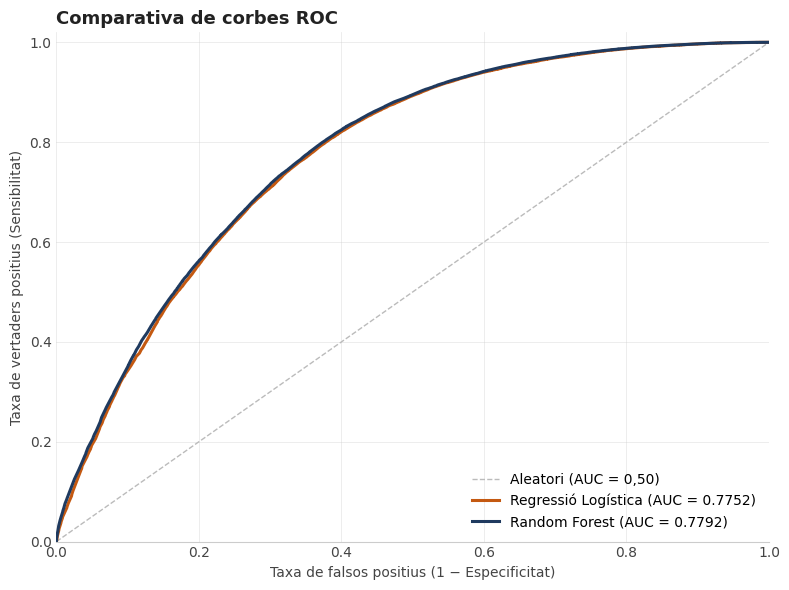

✓ Figura 3.1 guardada


In [10]:
# ============================================================
# FIGURA 3.1 — Comparativa de corbes ROC
# ============================================================
# Visualitza com es comparen els dos models en termes
# de trade-off entre sensibilitat (TPR) i 1-especificitat (FPR)

# Calcul corbes ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

# Paleta editorial coherent
COL_LR = "#C45911"     # taronja terrós
COL_RF = "#1F3A5F"     # blau marí

fig, ax = plt.subplots(figsize=(8, 6))

# Corba aleatori (diagonal)
ax.plot([0, 1], [0, 1], "--", color="#bbbbbb", linewidth=1, label="Aleatori (AUC = 0,50)")

# Logística
ax.plot(fpr_lr, tpr_lr, color=COL_LR, linewidth=2.2,
        label=f"Regressió Logística (AUC = {roc_auc_score(y_test, y_proba_lr):.4f})")

# Random Forest
ax.plot(fpr_rf, tpr_rf, color=COL_RF, linewidth=2.2,
        label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.4f})")

ax.set_title("Comparativa de corbes ROC", loc="left", fontweight="bold", color="#222", fontsize=13)
ax.set_xlabel("Taxa de falsos positius (1 − Especificitat)", color="#444")
ax.set_ylabel("Taxa de vertaders positius (Sensibilitat)", color="#444")
ax.tick_params(axis="both", colors="#444", length=0)
ax.grid(True, color="#cccccc", linestyle="-", linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_color("#cccccc")

ax.legend(loc="lower right", frameon=False, fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("../outputs/fig_3_1_roc_curves.png", dpi=160,
            bbox_inches="tight", facecolor="white")
plt.show()

print("✓ Figura 3.1 guardada")